In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [47]:

class NeuralNetworkScratch:
    def __init__(self, layer_sizes, lr=0.01, epochs=1000):
        """
        layer_sizes: list of ints, e.g. [input_dim, hidden1, ..., output_dim]
        """
        self.layer_sizes = layer_sizes
        self.lr = lr
        self.epochs = epochs
        self.weights = []
        self.biases = []
        self.rmse_history = []
        self.loss_history = []
        self._init_params()

    def _init_params(self):
        # Xavier initialization
        for i in range(len(self.layer_sizes)-1):
            in_dim = self.layer_sizes[i]
            out_dim = self.layer_sizes[i+1]
            limit = np.sqrt(6 / (in_dim + out_dim))
            W = np.random.uniform(-limit, limit, (out_dim, in_dim))
            b = np.zeros(out_dim)
            self.weights.append(W)
            self.biases.append(b)

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _sigmoid_derivative(self, a):
        return a * (1 - a)

    def _compute_loss(self, y, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=int)
        n_samples = X.shape[0]

        self.rmse_history = []
        self.loss_history = []

        for epoch in range(self.epochs):
            print(f'Starting epoch: {epoch}')
            # Forward pass
            activations = [X]
            for W, b in zip(self.weights, self.biases):
                z = activations[-1] @ W.T + b
                a = self._sigmoid(z)
                activations.append(a)

            y_pred = activations[-1].flatten()

            # Record metrics
            loss = self._compute_loss(y, y_pred)
            rmse = np.sqrt(np.mean((y_pred - y)**2))
            self.loss_history.append(loss)
            self.rmse_history.append(rmse)

            # Backward pass
            delta = (y_pred - y).reshape(-1, 1) * self._sigmoid_derivative(activations[-1])
            grads_W = []
            grads_b = []

            for l in reversed(range(len(self.weights))):
                a_prev = activations[l]
                grad_W = (delta.T @ a_prev) / n_samples
                grad_b = np.mean(delta, axis=0)
                grads_W.insert(0, grad_W)
                grads_b.insert(0, grad_b)
                if l > 0:
                    delta = (delta @ self.weights[l]) * self._sigmoid_derivative(activations[l])

            # Update
            for i in range(len(self.weights)):
                self.weights[i] -= self.lr * grads_W[i]
                self.biases[i]  -= self.lr * grads_b[i]
        return self

    def predict_proba(self, X):
        a = np.array(X, dtype=float)
        for W, b in zip(self.weights, self.biases):
            a = self._sigmoid(a @ W.T + b)
        return a.flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def plot_rmse(self):
        plt.figure()
        plt.plot(range(1, len(self.rmse_history)+1), self.rmse_history)
        plt.xlabel('Epoch')
        plt.ylabel('RMSE')
        plt.title('NN Training RMSE vs. Epoch')
        plt.show()

    def roc_auc_analysis(self, X, y):
        proba = self.predict_proba(X)
        auc = roc_auc_score(y, proba)
        fpr, tpr, _ = roc_curve(y, proba)
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0,1],[0,1], linestyle='--', color='gray')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('NN ROC Curve')
        plt.legend()
        plt.show()
        print(f"ROC AUC Score: {auc:.3f}")
        return auc

    def plot_confusion_matrix(self, X, y, threshold=0.5):
        preds = self.predict(X, threshold)
        cm = confusion_matrix(y, preds)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(cmap="Blues")
        plt.title('NN Confusion Matrix')
        plt.show()
        print("Confusion Matrix:\n", cm)

    def unit_tests(self):
        # Test 1: Loss and RMSE decrease
        np.random.seed(1)
        X_rand = np.random.randn(100, 4)
        true_w = np.array([1, -1, 0.5, 2])
        true_b = -0.2
        scores = X_rand.dot(true_w) + true_b
        y_rand = (scores > 0).astype(int)
        self.__init__([4, 3, 1], lr=0.1, epochs=50)
        self.fit(X_rand, y_rand)
        assert self.loss_history[0] > self.loss_history[-1], "Loss did not decrease"
        assert self.rmse_history[0] > self.rmse_history[-1], "RMSE did not decrease"

        # Test 2: Prediction shape matches
        preds = self.predict(X_rand)
        assert preds.shape == y_rand.shape, "Prediction shape mismatch"

        # Test 3: Simple separable data with single-layer network
        X_simple = np.array([[0], [1], [2], [3]])
        y_simple = np.array([0, 0, 1, 1])
        simple_nn = NeuralNetworkScratch([1, 1], lr=0.5, epochs=1000)
        simple_nn.fit(X_simple, y_simple)
        preds_simple = simple_nn.predict(X_simple)
        assert np.array_equal(preds_simple, y_simple), f"Simple data misclassified: {preds_simple}"

        print("All NeuralNetworkScratch unit tests passed!")
        return True



In [48]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# Convert categorical targets into binary targets (0=white, 1=red)
df['color'] = df['color'].map({'white': 0, 'red': 1})
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()

In [49]:
# Run unit tests
nn_model = NeuralNetworkScratch([4, 3, 1], lr=0.1, epochs=50)
nn_model.unit_tests()


Starting epoch: 0
Starting epoch: 1
Starting epoch: 2
Starting epoch: 3
Starting epoch: 4
Starting epoch: 5
Starting epoch: 6
Starting epoch: 7
Starting epoch: 8
Starting epoch: 9
Starting epoch: 10
Starting epoch: 11
Starting epoch: 12
Starting epoch: 13
Starting epoch: 14
Starting epoch: 15
Starting epoch: 16
Starting epoch: 17
Starting epoch: 18
Starting epoch: 19
Starting epoch: 20
Starting epoch: 21
Starting epoch: 22
Starting epoch: 23
Starting epoch: 24
Starting epoch: 25
Starting epoch: 26
Starting epoch: 27
Starting epoch: 28
Starting epoch: 29
Starting epoch: 30
Starting epoch: 31
Starting epoch: 32
Starting epoch: 33
Starting epoch: 34
Starting epoch: 35
Starting epoch: 36
Starting epoch: 37
Starting epoch: 38
Starting epoch: 39
Starting epoch: 40
Starting epoch: 41
Starting epoch: 42
Starting epoch: 43
Starting epoch: 44
Starting epoch: 45
Starting epoch: 46
Starting epoch: 47
Starting epoch: 48
Starting epoch: 49
Starting epoch: 0
Starting epoch: 1
Starting epoch: 2
Starti

True

In [50]:
# Fit
nn_model = NeuralNetworkScratch([12, 3, 1], lr=0.1, epochs=10000)
nn_model.fit(X, y)

Starting epoch: 0
Starting epoch: 1
Starting epoch: 2
Starting epoch: 3
Starting epoch: 4
Starting epoch: 5
Starting epoch: 6
Starting epoch: 7
Starting epoch: 8
Starting epoch: 9
Starting epoch: 10
Starting epoch: 11
Starting epoch: 12
Starting epoch: 13
Starting epoch: 14
Starting epoch: 15
Starting epoch: 16
Starting epoch: 17
Starting epoch: 18
Starting epoch: 19
Starting epoch: 20
Starting epoch: 21
Starting epoch: 22
Starting epoch: 23
Starting epoch: 24
Starting epoch: 25
Starting epoch: 26
Starting epoch: 27
Starting epoch: 28
Starting epoch: 29
Starting epoch: 30
Starting epoch: 31
Starting epoch: 32
Starting epoch: 33
Starting epoch: 34
Starting epoch: 35
Starting epoch: 36
Starting epoch: 37
Starting epoch: 38
Starting epoch: 39
Starting epoch: 40
Starting epoch: 41
Starting epoch: 42
Starting epoch: 43
Starting epoch: 44
Starting epoch: 45
Starting epoch: 46
Starting epoch: 47
Starting epoch: 48
Starting epoch: 49
Starting epoch: 50
Starting epoch: 51
Starting epoch: 52
Sta

## Iteration
- **Steep Early Descent**  
  - In the first ~2 000 epochs, RMSE plunges from ~0.50 down to ~0.25, showing the network rapidly learns the major linear and mildly nonlinear patterns.  
- **Gradual Convergence**  
  - From ~2 000 to ~7 000 epochs, RMSE continues to decline more slowly, edging toward ~0.20. This reflects fine‐tuning of weights as the model hones in on subtler feature interactions.  
- **Late‐Stage Oscillations**  
  - After ~7 000 epochs, the curve becomes noisy: periodic spikes around ~0.22–0.26 indicate the optimizer is “jiggling” the parameters around a shallow minimum.  
  - Possible causes: a learning rate that’s now too large for the small gradients, or lack of momentum/regularization to dampen updates.  

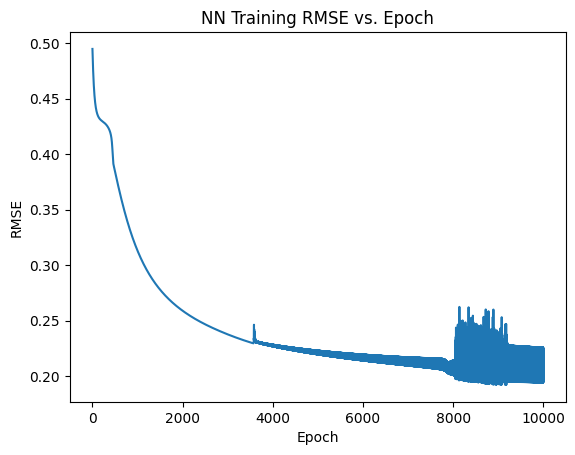

In [51]:
nn_model.plot_rmse()

## Results
- The ROC AUC analysis yielded a score of approximately 0.96, which is very favorable and suggests that the model is robust model (i.e. that the accuracy in the confusion matrix stands up to reshuffling of training and test sets)

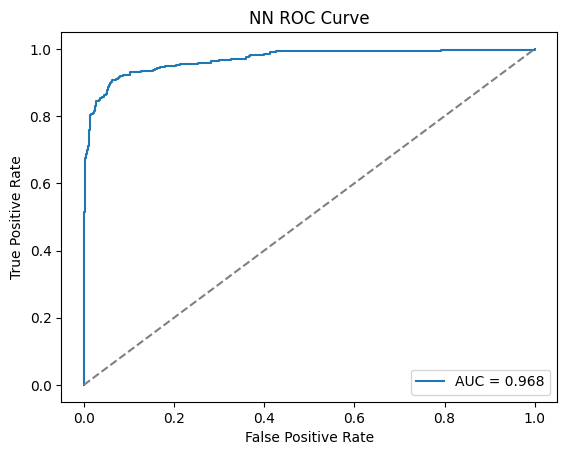

ROC AUC Score: 0.968


0.9684274104985724

In [52]:
nn_model.roc_auc_analysis(X_test, y_test)